<a href="https://colab.research.google.com/github/ARehman007-max/internship/blob/main/Task10_Feature_Engineering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

# Load the Tips dataset
df = sns.load_dataset("tips")

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (244, 7)

First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Data types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Basic statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Categorical columns unique values:
sex: ['Female', 'Male']
Categories (2, object): ['Male', 'Female']
smoker: ['No', 'Yes']
Categories (2, object): ['Yes', 'No']
day: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
time: ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']


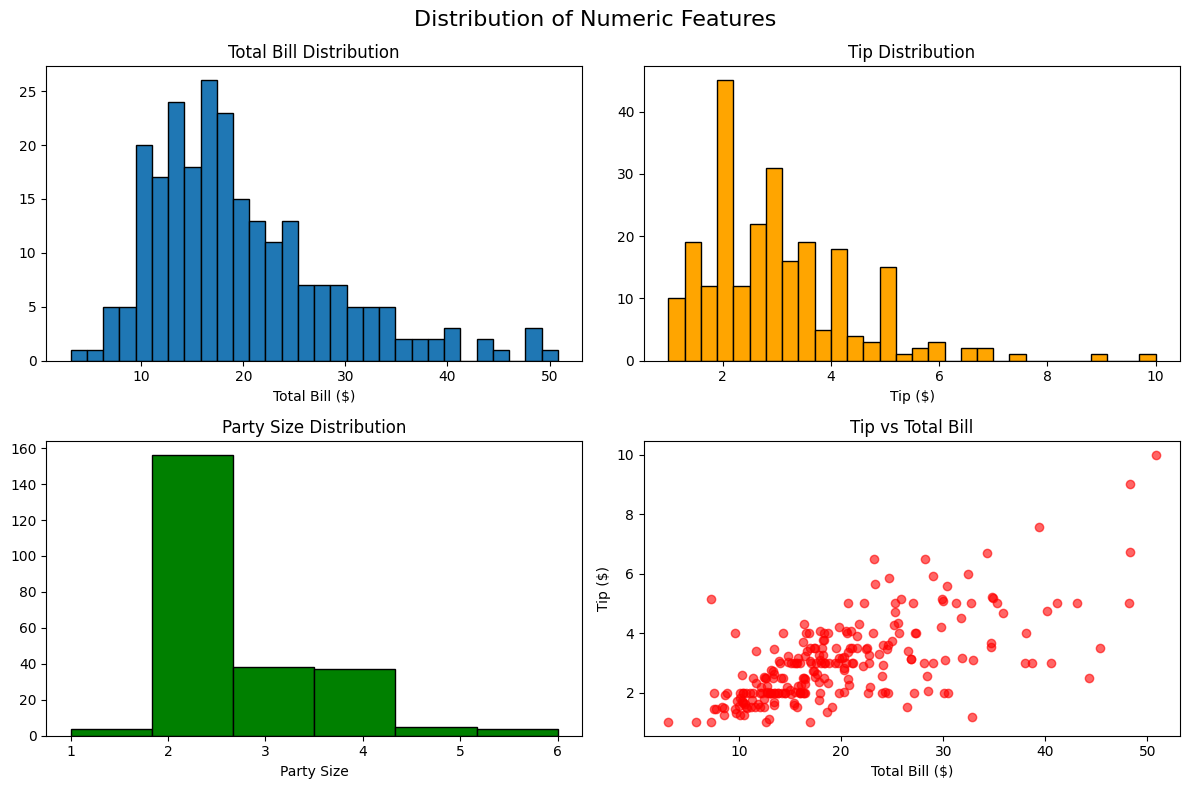

In [2]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check categorical columns
print("\nCategorical columns unique values:")
categorical_cols = ['sex', 'smoker', 'day', 'time']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

# Visualize distributions of numeric columns
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Numeric Features', fontsize=16)

axes[0, 0].hist(df['total_bill'], bins=30, edgecolor='black')
axes[0, 0].set_title('Total Bill Distribution')
axes[0, 0].set_xlabel('Total Bill ($)')

axes[0, 1].hist(df['tip'], bins=30, edgecolor='black', color='orange')
axes[0, 1].set_title('Tip Distribution')
axes[0, 1].set_xlabel('Tip ($)')

axes[1, 0].hist(df['size'], bins=6, edgecolor='black', color='green')
axes[1, 0].set_title('Party Size Distribution')
axes[1, 0].set_xlabel('Party Size')

axes[1, 1].scatter(df['total_bill'], df['tip'], alpha=0.6, color='red')
axes[1, 1].set_title('Tip vs Total Bill')
axes[1, 1].set_xlabel('Total Bill ($)')
axes[1, 1].set_ylabel('Tip ($)')

plt.tight_layout()
plt.show()

In [3]:
# Create a copy of the dataframe for feature engineering
df_encoded = df.copy()

# Label Encoding for ordinal data (if applicable)
# 'day' has a natural order (Thursday < Friday < Saturday < Sunday)
day_order = {'Thur': 0, 'Fri': 1, 'Sat': 2, 'Sun': 3}
df_encoded['day_label_encoded'] = df_encoded['day'].map(day_order)

# Label Encoding using sklearn
label_encoder = LabelEncoder()
df_encoded['sex_label_encoded'] = label_encoder.fit_transform(df_encoded['sex'])
df_encoded['smoker_label_encoded'] = label_encoder.fit_transform(df_encoded['smoker'])
df_encoded['time_label_encoded'] = label_encoder.fit_transform(df_encoded['time'])

print("DataFrame with Label Encoded columns:")
print(df_encoded[['sex', 'sex_label_encoded', 'smoker', 'smoker_label_encoded',
                   'time', 'time_label_encoded', 'day', 'day_label_encoded']].head())

# One-Hot Encoding for nominal data
df_onehot = pd.get_dummies(df, columns=['sex', 'smoker', 'day', 'time'], drop_first=True)

print("\nDataFrame with One-Hot Encoded columns:")
print(df_onehot.head())
print("\nNew columns after one-hot encoding:")
print(df_onehot.columns.tolist())

DataFrame with Label Encoded columns:
      sex  sex_label_encoded smoker  smoker_label_encoded    time  \
0  Female                  0     No                     0  Dinner   
1    Male                  1     No                     0  Dinner   
2    Male                  1     No                     0  Dinner   
3    Male                  1     No                     0  Dinner   
4  Female                  0     No                     0  Dinner   

   time_label_encoded  day day_label_encoded  
0                   0  Sun                 3  
1                   0  Sun                 3  
2                   0  Sun                 3  
3                   0  Sun                 3  
4                   0  Sun                 3  

DataFrame with One-Hot Encoded columns:
   total_bill   tip  size  sex_Female  smoker_No  day_Fri  day_Sat  day_Sun  \
0       16.99  1.01     2        True       True    False    False     True   
1       10.34  1.66     3       False       True    False    False

In [4]:
# Create new features from existing ones
df_features = df.copy()

# Tip percentage
df_features['tip_percentage'] = (df_features['tip'] / df_features['total_bill']) * 100

# Average bill per person
df_features['bill_per_person'] = df_features['total_bill'] / df_features['size']

# Tip per person
df_features['tip_per_person'] = df_features['tip'] / df_features['size']

# Is weekend (Saturday or Sunday)
df_features['is_weekend'] = df_features['day'].isin(['Sat', 'Sun']).astype(int)

# Is dinner time
df_features['is_dinner'] = df_features['time'].isin(['Dinner']).astype(int)

# Interaction feature: total_bill × size
df_features['bill_size_interaction'] = df_features['total_bill'] * df_features['size']

print("DataFrame with new engineered features:")
print(df_features.head())
print("\nNew feature statistics:")
print(df_features[['tip_percentage', 'bill_per_person', 'tip_per_person',
                    'is_weekend', 'is_dinner', 'bill_size_interaction']].describe())

DataFrame with new engineered features:
   total_bill   tip     sex smoker  day    time  size  tip_percentage  \
0       16.99  1.01  Female     No  Sun  Dinner     2        5.944673   
1       10.34  1.66    Male     No  Sun  Dinner     3       16.054159   
2       21.01  3.50    Male     No  Sun  Dinner     3       16.658734   
3       23.68  3.31    Male     No  Sun  Dinner     2       13.978041   
4       24.59  3.61  Female     No  Sun  Dinner     4       14.680765   

   bill_per_person  tip_per_person  is_weekend  is_dinner  \
0         8.495000        0.505000           1          1   
1         3.446667        0.553333           1          1   
2         7.003333        1.166667           1          1   
3        11.840000        1.655000           1          1   
4         6.147500        0.902500           1          1   

   bill_size_interaction  
0                  33.98  
1                  31.02  
2                  63.03  
3                  47.36  
4                  

In [5]:
# Binning continuous variables
df_binned = df.copy()

# Bin total_bill into categories
df_binned['bill_category'] = pd.cut(
    df_binned['total_bill'],
    bins=[0, 15, 30, 100],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

# Bin tip into categories
df_binned['tip_category'] = pd.cut(
    df_binned['tip'],
    bins=[0, 2, 4, 6, 20],
    labels=['Very Low', 'Low', 'Medium', 'High'],
    include_lowest=True
)

# Bin party size
df_binned['size_category'] = pd.cut(
    df_binned['size'],
    bins=[0, 2, 4, 6],
    labels=['Small', 'Medium', 'Large'],
    include_lowest=True
)

print("DataFrame with binned columns:")
print(df_binned[['total_bill', 'bill_category', 'tip', 'tip_category',
                  'size', 'size_category']].head(10))

# Count of observations in each category
print("\nBill category counts:")
print(df_binned['bill_category'].value_counts())
print("\nSize category counts:")
print(df_binned['size_category'].value_counts())

DataFrame with binned columns:
   total_bill bill_category   tip tip_category  size size_category
0       16.99        Medium  1.01     Very Low     2         Small
1       10.34           Low  1.66     Very Low     3        Medium
2       21.01        Medium  3.50          Low     3        Medium
3       23.68        Medium  3.31          Low     2         Small
4       24.59        Medium  3.61          Low     4        Medium
5       25.29        Medium  4.71       Medium     4        Medium
6        8.77           Low  2.00     Very Low     2         Small
7       26.88        Medium  3.12          Low     4        Medium
8       15.04        Medium  1.96     Very Low     2         Small
9       14.78           Low  3.23          Low     2         Small

Bill category counts:
bill_category
Medium    132
Low        80
High       32
Name: count, dtype: int64

Size category counts:
size_category
Small     160
Medium     75
Large       9
Name: count, dtype: int64


In [6]:
# Feature Scaling
df_scaled = df.copy()

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply StandardScaler
df_scaled['total_bill_standard'] = standard_scaler.fit_transform(df_scaled[['total_bill']])
df_scaled['tip_standard'] = standard_scaler.fit_transform(df_scaled[['tip']])

# Apply MinMaxScaler
df_scaled['total_bill_minmax'] = minmax_scaler.fit_transform(df_scaled[['total_bill']])
df_scaled['tip_minmax'] = minmax_scaler.fit_transform(df_scaled[['tip']])

print("DataFrame with scaled columns:")
print(df_scaled[['total_bill', 'total_bill_standard', 'total_bill_minmax',
                  'tip', 'tip_standard', 'tip_minmax']].head())

# Show the differences between scaling methods
print("\nStandardScaler statistics (should be mean≈0, std≈1):")
print(f"Total Bill Standard - Mean: {df_scaled['total_bill_standard'].mean():.4f}, Std: {df_scaled['total_bill_standard'].std():.4f}")

print("\nMinMaxScaler statistics (should be min=0, max=1):")
print(f"Total Bill MinMax - Min: {df_scaled['total_bill_minmax'].min():.4f}, Max: {df_scaled['total_bill_minmax'].max():.4f}")

DataFrame with scaled columns:
   total_bill  total_bill_standard  total_bill_minmax   tip  tip_standard  \
0       16.99            -0.314711           0.291579  1.01     -1.439947   
1       10.34            -1.063235           0.152283  1.66     -0.969205   
2       21.01             0.137780           0.375786  3.50      0.363356   
3       23.68             0.438315           0.431713  3.31      0.225754   
4       24.59             0.540745           0.450775  3.61      0.443020   

   tip_minmax  
0    0.001111  
1    0.073333  
2    0.277778  
3    0.256667  
4    0.290000  

StandardScaler statistics (should be mean≈0, std≈1):
Total Bill Standard - Mean: -0.0000, Std: 1.0021

MinMaxScaler statistics (should be min=0, max=1):
Total Bill MinMax - Min: 0.0000, Max: 1.0000


Skewness of numeric features:
total_bill    1.133213
tip           1.465451
size          1.447882
dtype: float64


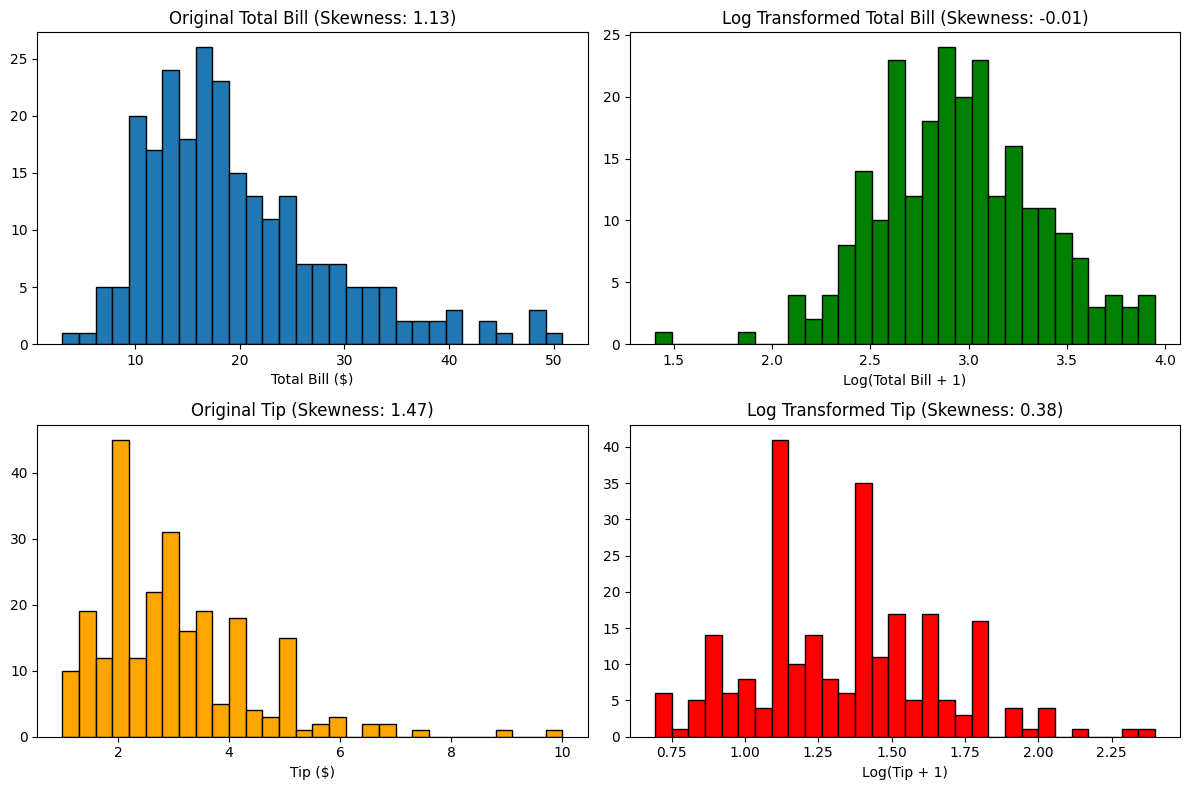


DataFrame with log-transformed features:
   total_bill  total_bill_log   tip   tip_log
0       16.99        2.889816  1.01  0.698135
1       10.34        2.428336  1.66  0.978326
2       21.01        3.091497  3.50  1.504077
3       23.68        3.205993  3.31  1.460938
4       24.59        3.242202  3.61  1.528228


In [7]:
# Check skewness of numeric features
print("Skewness of numeric features:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].skew())

# Visualize original vs transformed data
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original total_bill
axes[0, 0].hist(df['total_bill'], bins=30, edgecolor='black')
axes[0, 0].set_title(f'Original Total Bill (Skewness: {df["total_bill"].skew():.2f})')
axes[0, 0].set_xlabel('Total Bill ($)')

# Log transformed total_bill
df_log = df.copy()
df_log['total_bill_log'] = np.log1p(df_log['total_bill'])
axes[0, 1].hist(df_log['total_bill_log'], bins=30, edgecolor='black', color='green')
axes[0, 1].set_title(f'Log Transformed Total Bill (Skewness: {df_log["total_bill_log"].skew():.2f})')
axes[0, 1].set_xlabel('Log(Total Bill + 1)')

# Original tip
axes[1, 0].hist(df['tip'], bins=30, edgecolor='black', color='orange')
axes[1, 0].set_title(f'Original Tip (Skewness: {df["tip"].skew():.2f})')
axes[1, 0].set_xlabel('Tip ($)')

# Log transformed tip
df_log['tip_log'] = np.log1p(df_log['tip'])
axes[1, 1].hist(df_log['tip_log'], bins=30, edgecolor='black', color='red')
axes[1, 1].set_title(f'Log Transformed Tip (Skewness: {df_log["tip_log"].skew():.2f})')
axes[1, 1].set_xlabel('Log(Tip + 1)')

plt.tight_layout()
plt.show()

# Apply log transformation to skewed features
df_transformed = df.copy()
df_transformed['total_bill_log'] = np.log1p(df_transformed['total_bill'])
df_transformed['tip_log'] = np.log1p(df_transformed['tip'])

print("\nDataFrame with log-transformed features:")
print(df_transformed[['total_bill', 'total_bill_log', 'tip', 'tip_log']].head())

Correlation with target variable (tip):
tip           1.000000
total_bill    0.675734
size          0.489299
Name: tip, dtype: float64


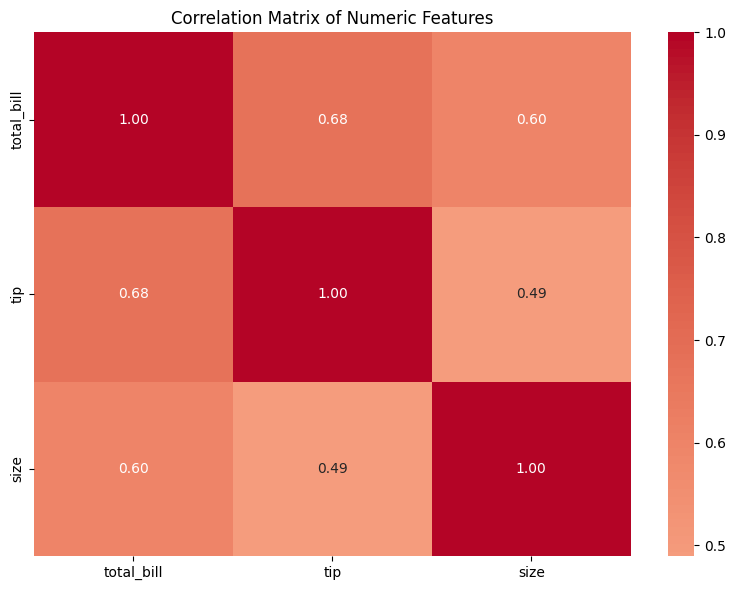


No highly correlated feature pairs found (threshold > 0.8)


In [8]:
# Feature Selection using correlation
df_selection = df.copy()

# Calculate correlation matrix
correlation_matrix = df_selection.select_dtypes(include=[np.number]).corr()

print("Correlation with target variable (tip):")
print(correlation_matrix['tip'].sort_values(ascending=False))

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Identify highly correlated features (excluding self-correlation)
threshold = 0.8
high_corr_features = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            feature_pair = (correlation_matrix.columns[i], correlation_matrix.columns[j],
                          correlation_matrix.iloc[i, j])
            high_corr_features.append(feature_pair)

if high_corr_features:
    print("\nHighly correlated feature pairs (threshold > 0.8):")
    for pair in high_corr_features:
        print(f"{pair[0]} - {pair[1]}: {pair[2]:.3f}")
else:
    print("\nNo highly correlated feature pairs found (threshold > 0.8)")

In [9]:
# Complete feature engineering pipeline for the Tips dataset
def engineer_features(df):
    """
    Apply all feature engineering steps to the Tips dataset
    """
    df_engineered = df.copy()

    # 1. Create new features
    df_engineered['tip_percentage'] = (df_engineered['tip'] / df_engineered['total_bill']) * 100
    df_engineered['bill_per_person'] = df_engineered['total_bill'] / df_engineered['size']
    df_engineered['tip_per_person'] = df_engineered['tip'] / df_engineered['size']
    df_engineered['is_weekend'] = df_engineered['day'].isin(['Sat', 'Sun']).astype(int)

    # 2. Binning
    df_engineered['bill_category'] = pd.cut(
        df_engineered['total_bill'],
        bins=[0, 15, 30, 100],
        labels=['Low', 'Medium', 'High']
    )

    # 3. Log transformation
    df_engineered['total_bill_log'] = np.log1p(df_engineered['total_bill'])
    df_engineered['tip_log'] = np.log1p(df_engineered['tip'])

    # 4. Scaling
    scaler = StandardScaler()
    df_engineered['total_bill_scaled'] = scaler.fit_transform(df_engineered[['total_bill']])
    df_engineered['tip_scaled'] = scaler.fit_transform(df_engineered[['tip']])

    # 5. One-hot encoding for categorical variables
    df_engineered = pd.get_dummies(
        df_engineered,
        columns=['sex', 'smoker', 'day', 'time'],
        drop_first=True
    )

    return df_engineered

# Apply the complete pipeline
df_final = engineer_features(df)

print("Final engineered dataset:")
print(f"Shape: {df_final.shape}")
print(f"Number of features: {df_final.shape[1]}")
print("\nAll columns:")
for i, col in enumerate(df_final.columns, 1):
    print(f"{i}. {col}")

Final engineered dataset:
Shape: (244, 18)
Number of features: 18

All columns:
1. total_bill
2. tip
3. size
4. tip_percentage
5. bill_per_person
6. tip_per_person
7. is_weekend
8. bill_category
9. total_bill_log
10. tip_log
11. total_bill_scaled
12. tip_scaled
13. sex_Female
14. smoker_No
15. day_Fri
16. day_Sat
17. day_Sun
18. time_Dinner


In [10]:
# Demonstrate how engineered features can be used in a model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Prepare data with engineered features
df_model = engineer_features(df)

# Select features and target
# Remove non-numeric and target columns
X = df_model.drop(['tip', 'tip_log', 'tip_scaled', 'tip_per_person'], axis=1)
y = df_model['tip']

# Handle remaining categorical columns if any
X = pd.get_dummies(X, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance with Engineered Features:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

# Compare with baseline (using only total_bill)
X_baseline = df[['total_bill']]
y_baseline = df['tip']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_baseline, y_baseline,
                                                             test_size=0.2, random_state=42)

model_baseline = LinearRegression()
model_baseline.fit(X_train_b, y_train_b)
y_pred_baseline = model_baseline.predict(X_test_b)

mse_baseline = mean_squared_error(y_test_b, y_pred_baseline)
r2_baseline = r2_score(y_test_b, y_pred_baseline)

print("\nBaseline Model Performance (only total_bill):")
print(f"Mean Squared Error: {mse_baseline:.4f}")
print(f"R² Score: {r2_baseline:.4f}")

print(f"\nImprovement in R² Score: {(r2 - r2_baseline)*100:.2f}%")

Model Performance with Engineered Features:
Mean Squared Error: 0.1363
R² Score: 0.8910

Baseline Model Performance (only total_bill):
Mean Squared Error: 0.5688
R² Score: 0.5449

Improvement in R² Score: 34.60%
